# Notebook 16 — Modelo de Previsión v2
## Ampliación de Historial · Split ABC · Regularización · Filtro SKUs Modelables

> **Proyecto CRUZBER | MDA-13 | Forecasting Semanal B2B**  
> Continuación de Notebook 15 (baseline v1)

**Objetivo:** Implementar las cuatro mejoras prioritarias identificadas en v1 para reducir el MAPE desde el rango 43–59% hasta el objetivo de 30–40%.

## Punto de Partida: Qué Aprendimos en la v1

El Notebook 15 construyó el **baseline** con tres modelos CatBoost entrenados sobre datos 2022–2024. Estos fueron los resultados reales de ejecución:

| Modelo | MAE | MAPE | R² | Problema identificado |
|--------|-----|------|----|-----------------------|
| A — Nacional (todos canales) | 2,55 ud. | 59,2% | 0,642 | Overfitting 37,7% · SKUs esporádicos arrastran MAPE |
| B — Tradicional × Región | 0,88 ud. | 42,8% | 0,520 | Historial corto · `lag_52w` con pocas referencias |
| C — FLEET Nacional | 4,39 ud. | 88,6% | 0,413 | Alta variabilidad · dataset pequeño |

> **Benchmark clave:** El modelo ML ya supera en 2,8x la previsión interna de CRUZBER (MAPE 59,1% vs 165,4%). Esta v2 busca consolidar esa ventaja con mejoras metodológicas.

---

## Las Cuatro Mejoras de esta v2

| # | Mejora | Lógica de negocio | Impacto esperado |
|---|--------|-------------------|------------------|
| **M1** | **Split ABC** — modelo separado por clase de SKU | Un SKU con ventas semanales regulares (tipo A) y uno que vende 3 veces al año (tipo C) no pueden compartir el mismo modelo: el ruido de los C destruye la señal de los A | −15 a −20 pts MAPE |
| **M2** | **Historial 2020–2024** — de 3 a 5 años | Con solo 3 años, el `lag_52w` (patrón del año anterior) tiene una sola referencia. Con 5 años tiene 3–4, lo que estabiliza la señal estacional | −5 a −10 pts MAPE |
| **M3** | **Regularización** — depth=4, lr=0.05, l2=10, min_data_in_leaf=20 | La brecha RMSE train/test del 37,7% indica memorización del historial. Parámetros más conservadores generalizan mejor a semanas nuevas | −5 a −8 pts MAPE |
| **M4** | **Filtro SKUs modelables** — mínimo 8 semanas de historial | Incluir SKUs con 1–2 registros de venta introduce ruido puro: el modelo no puede aprender ningún patrón. Para estos usamos un pronóstico naive (media histórica) | −5 a −10 pts MAPE |

**Resultado esperado:** MAPE en rango 30–40% (frente a 43–59% en v1).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
import re, warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
sns.set_palette('husl')
RANDOM_STATE = 42
print('Librerias cargadas.')

Librerias cargadas.


## 1. Carga de Datos Transaccionales

El fichero `LineasAlbaranCliente.xlsx` es la fuente de verdad del proyecto: contiene **cada línea de albarán de venta** emitida por CRUZBER desde 2019.

Es la base sobre la que construiremos todos los modelos. No usamos ningún dato externo de panel ni estimaciones: solo las ventas reales.

In [2]:
df_raw = pd.read_excel('../Datasets/Datos Internos/LineasAlbaranCliente.xlsx')
print(f'Dataset bruto: {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas')
print(f'Columnas: {df_raw.columns.tolist()}')
df_raw.head(3)

Dataset bruto: 938,230 filas x 20 columnas
Columnas: ['CodigoCliente', 'SerieAlbaran', 'NumeroAlbaran', 'FechaAlbaran', 'CodigoArticulo', 'CodigoAlmacen', 'Unidades', 'Precio', 'PrecioCoste', 'ImporteDescuento', 'ImporteCoste', 'ImporteBruto', 'ImporteNeto', 'ImporteProntoPago', 'BaseImponible', 'ImporteLiquido', '%Descuento', '%Descuento2', 'PorMargenBeneficio', 'MargenBeneficio']


,CodigoCliente,SerieAlbaran,NumeroAlbaran,FechaAlbaran,CodigoArticulo,CodigoAlmacen,Unidades,Precio,PrecioCoste,ImporteDescuento,ImporteCoste,ImporteBruto,ImporteNeto,ImporteProntoPago,BaseImponible,ImporteLiquido,%Descuento,%Descuento2,PorMargenBeneficio,MargenBeneficio
0,18530,21,29242,"viernes, 30 de julio de 2021",940-540,0,3.0,170.0,120.000000,0.0,360.000000,510.0,510.0,10.20,499.80,499.80,0.0,0.0,27.971188,139.800000
1,18530,21,29242,"viernes, 30 de julio de 2021",940-006,0,357.0,18.5,14.086994,0.0,5029.056931,6604.5,6604.5,132.09,6472.41,6472.41,0.0,0.0,22.300087,1443.353069
2,18530,21,29242,"viernes, 30 de julio de 2021",940-007,0,204.0,18.0,13.650033,0.0,2784.606832,3672.0,3672.0,73.44,3598.56,3598.56,0.0,0.0,22.618858,813.953168


## 2. Limpieza y Filtrado: 5 Años de Historial (2020–2024)

### Por qué ampliamos de 2022–2024 a 2020–2024

En la v1 usamos solo 3 años de datos. El principal problema identificado fue que el `lag_52w` (demanda de la misma semana del año anterior) tenía solo 1–2 observaciones de referencia para muchos SKUs. Esto impide que el modelo aprenda bien la estacionalidad interanual.

Con 5 años disponibles:
- `lag_52w` tiene hasta 4 referencias históricas → calibración mucho más estable
- Las medias móviles de largo plazo (roll_12w) tienen más densidad
- Los SKUs tipo B que venden 2–3 veces al año acumulan suficientes observaciones

### Filtros aplicados
1. **Nacional:** series numéricas de albarán (`SerieAlbaran` numérico = España)
2. **2020–2024:** descartamos 2019 (año incompleto en la fuente)
3. **Devoluciones:** eliminamos líneas con `Unidades ≤ 0` (no son demanda real)

In [3]:
MONTH_MAP = {
    'enero':1,'febrero':2,'marzo':3,'abril':4,'mayo':5,'junio':6,
    'julio':7,'agosto':8,'septiembre':9,'octubre':10,'noviembre':11,'diciembre':12
}

def parse_spanish_date(date_str):
    if pd.isna(date_str): return pd.NaT
    s = str(date_str).lower().strip()
    m = re.search(r'(\d{1,2})\s+de\s+(\w+)\s+de\s+(\d{4})', s)
    if m:
        day, month_name, year = m.groups()
        month = MONTH_MAP.get(month_name)
        if month:
            return pd.Timestamp(int(year), month, int(day))
    return pd.NaT

# 1. Filtro nacional (series numericas = espana)
df_nac = df_raw[df_raw['SerieAlbaran'].astype(str).str.match(r'^\d+')].copy()

# 2. Parsear fechas en formato espanol
print('Parseando fechas...')
df_nac['fecha'] = df_nac['FechaAlbaran'].apply(parse_spanish_date)
df_nac = df_nac.dropna(subset=['fecha'])
df_nac['anio']       = df_nac['fecha'].dt.isocalendar().year.astype(int)
df_nac['semana_anio'] = df_nac['fecha'].dt.isocalendar().week.astype(int)

# 3. Filtro 2020-2024 (MEJORA 2: +2 anos vs v1)
n_antes = len(df_nac)
df_nac = df_nac[df_nac['anio'].between(2020, 2024)].copy()
n_periodo = len(df_nac)

# 4. Eliminar devoluciones (Unidades <= 0)
df_nac = df_nac[df_nac['Unidades'] > 0].copy()
n_limpio = len(df_nac)

print(f'Total bruto             : {len(df_raw):>10,}')
print(f'Tras filtro nacional    : {n_antes:>10,}')
print(f'Tras filtro 2020-2024   : {n_periodo:>10,}  [+{n_periodo - len(df_raw[df_raw["SerieAlbaran"].astype(str).str.match(r"^\\d+") & df_raw["FechaAlbaran"].apply(lambda x: str(x)).str.contains("202[2-4]", na=False)]):,} filas nuevas vs v1]')
print(f'Devoluciones eliminadas : {n_periodo - n_limpio:>10,}')
print(f'Dataset limpio          : {n_limpio:>10,}')
print(f'Rango: {df_nac["fecha"].min().date()} => {df_nac["fecha"].max().date()}')

Parseando fechas...
Total bruto             :    938,230
Tras filtro nacional    :    893,280
Tras filtro 2020-2024   :    759,000  [+759,000 filas nuevas vs v1]
Devoluciones eliminadas :     17,506
Dataset limpio          :    741,494
Rango: 2020-01-03 => 2024-09-26


## 3. Enriquecimiento con Maestros

Unimos las transacciones con los ficheros maestros para añadir:
- **Canal de venta** (Tradicional, FLEET, Nueva Distribución) → segmentación de modelos
- **Región geográfica** (Norte, Noreste, Centro, Sur, Noroeste) → modelo B
- **Clasificación ABC** y características de producto → features del modelo

Este paso no cambia respecto a v1: los maestros son estables y el código de enriquecimiento ya fue validado.

In [4]:
# --- Maestro de clientes ---
df_clientes = pd.read_excel(
    '../Datasets/Datos Internos/MaestroClientes.xlsx',
    usecols=['CodigoCliente','Municipio','Provincia','Zona',
             'TipoCruz','CodigoProvincia','CodigoAutonomia','BajaEmpresaLc']
)
df_clientes = df_clientes.drop_duplicates(subset='CodigoCliente', keep='first')

# --- Canales (columnas por posicion para evitar encoding issues) ---
df_canales = pd.read_excel(
    '../Datasets/Datos Internos/Agrupacion Canales venta.xlsx',
    usecols=[0, 1, 2]
)
df_canales.columns = ['TipoCruz', 'agrupacion_canal', 'tipo_agrupacion']
df_canales = df_canales.drop_duplicates(subset='TipoCruz')

# Join 1: transacciones -> clientes
df_enriched = df_nac.merge(
    df_clientes[['CodigoCliente','Provincia','CodigoProvincia','CodigoAutonomia','TipoCruz','BajaEmpresaLc']],
    on='CodigoCliente', how='left'
).reset_index(drop=True)

# Join 2: -> canal
df_enriched = df_enriched.merge(df_canales, on='TipoCruz', how='left').reset_index(drop=True)

# Solo canal Nacional
df_esp = df_enriched[df_enriched['tipo_agrupacion'] == 'Nacional'].copy().reset_index(drop=True)

# Fusionar Primeros Equipos en Tradicional
df_esp['agrupacion_canal'] = df_esp['agrupacion_canal'].replace('Primeros Equipos', 'Tradicional')

# Mapeo autonomia -> region (clave numerica: sin encoding issues)
autonomia_to_region = {
    59:'Noreste', 65:'Noreste', 67:'Noreste',
    53:'Norte',   75:'Norte',   62:'Norte',   63:'Norte',
    64:'Centro',  57:'Centro',  55:'Centro',  58:'Centro',
    61:'Sur',     70:'Sur',     54:'Sur',     66:'Sur',
    71:'Noroeste',52:'Noroeste',56:'Noroeste',
    60:'Canarias'
}
df_esp['region'] = df_esp['CodigoAutonomia'].map(autonomia_to_region).fillna('Desconocido')

canal_dist = df_esp['agrupacion_canal'].value_counts()
print(f'Filas nacionales: {len(df_esp):,} | Clientes: {df_esp["CodigoCliente"].nunique():,}')
print(f'\nDistribucion por canal:')
print(canal_dist)
print(f'\nDistribucion por region:')
print(df_esp['region'].value_counts())

Filas nacionales: 509,098 | Clientes: 2,027

Distribucion por canal:
agrupacion_canal
Tradicional           306407
Nueva Distribución    161973
FLEET                  40718
Name: count, dtype: int64

Distribucion por region:
region
Desconocido    237634
Sur            122307
Norte           52040
Noreste         51627
Noroeste        25735
Centro          19755
Name: count, dtype: int64


In [5]:
# --- Maestro de articulos ---
df_art = pd.read_excel(
    '../Datasets/Datos Internos/MaestroArticulos.xlsx',
    usecols=['CodigoArticulo','AgrupacionListado','TipoABC',
             'PrevisionVentasAA','FactorCrecimiento','AreaCompetenciaLc','TarifaNacional','Obsoleto']
)
df_art = df_art[df_art['Obsoleto'] != 'Si'].copy()  # FILTRO: eliminar articulos obsoletos (47.7% del catalogo)
df_art['CodigoArticulo']       = df_art['CodigoArticulo'].astype(str).str.strip()
df_art['PrevisionVentasAA']    = pd.to_numeric(df_art['PrevisionVentasAA'],  errors='coerce').fillna(0)
df_art['FactorCrecimiento']    = pd.to_numeric(df_art['FactorCrecimiento'],  errors='coerce').fillna(1.0)
df_art['TarifaNacional']       = pd.to_numeric(df_art['TarifaNacional'],     errors='coerce').fillna(0)
df_art['AreaCompetenciaLc']    = df_art['AreaCompetenciaLc'].fillna('Desconocido').astype(str)
df_art['AgrupacionListado']    = df_art['AgrupacionListado'].astype(str).str.strip()
df_art['prevision_semanal_aa'] = df_art['PrevisionVentasAA'] / 52

# --- Familias de articulos ---
df_fam = pd.read_excel(
    '../Datasets/Datos Internos/Familias Articulos.xlsx',
    usecols=['AgrupacionListado','CR_GamaProducto','CR_TipoProducto','CR_MaterialAgrupacion']
)
df_fam['AgrupacionListado'] = df_fam['AgrupacionListado'].astype(str).str.strip()
for col in ['CR_GamaProducto','CR_TipoProducto','CR_MaterialAgrupacion']:
    df_fam[col] = df_fam[col].fillna('Desconocido').astype(str)

df_sku = df_art.merge(df_fam, on='AgrupacionListado', how='left')
for col in ['CR_GamaProducto','CR_TipoProducto','CR_MaterialAgrupacion']:
    df_sku[col] = df_sku[col].fillna('Desconocido')
df_sku = df_sku.drop_duplicates(subset='CodigoArticulo')

df_esp['CodigoArticulo'] = df_esp['CodigoArticulo'].astype(str).str.strip()
df_master = df_esp.merge(df_sku, on='CodigoArticulo', how='left')

df_master['TipoABC'] = df_master['TipoABC'].fillna('C').astype(str)
for col in ['CR_GamaProducto','CR_TipoProducto','CR_MaterialAgrupacion','AreaCompetenciaLc']:
    df_master[col] = df_master[col].fillna('Desconocido').astype(str)
for col in ['FactorCrecimiento','TarifaNacional','prevision_semanal_aa','PrevisionVentasAA']:
    df_master[col] = df_master[col].fillna(0)

df_master = df_master.rename(columns={
    'CodigoArticulo': 'codigo_articulo',
    'Unidades':       'unidades',
    'ImporteNeto':    'importe_neto',
    'TipoABC':        'tipo_abc',
    'Provincia':      'provincia'
})

print(f'Dataset maestro: {df_master.shape[0]:,} filas x {df_master.shape[1]} columnas')
print(f'Clientes: {df_master["CodigoCliente"].nunique():,} | SKUs: {df_master["codigo_articulo"].nunique():,}')
print(f'Importe neto total: EUR {df_master["importe_neto"].sum():,.0f}')
print(f'Periodo: {df_master["fecha"].min().date()} => {df_master["fecha"].max().date()}')

Dataset maestro: 509,098 filas x 42 columnas
Clientes: 2,027 | SKUs: 3,398
Importe neto total: EUR 32,330,535
Periodo: 2020-01-03 => 2024-09-26


## 4. Datos Externos: Clima y Ciclismo

Igual que en v1, incorporamos dos señales externas:

- **Temperatura y precipitación semanal** (`clima_semanal_openmeteo.csv`): en el sector ciclista la demanda de accesorios y ropa es muy sensible al tiempo. Semanas lluviosas o frías deprime la compra; primaveras secas la disparan.
- **Calendario de pruebas ciclistas** (`Calendario Ciclismo 22_24.xlsx`): las grandes carreras regionales (Vuelta a Cataluña, Volta, etc.) generan picos de demanda tanto en FLEET (equipos) como en Tradicional (tiendas del recorrido).

Con el historial ampliado a 2020–2024, la señal climática tiene más peso porque el modelo puede aprender correlaciones a lo largo de varios ciclos estacionales.

In [6]:
# ── Datos de Clima ───────────────────────────────────────────────────────────
df_clima_raw = pd.read_csv('../Datasets/clima_semanal_openmeteo.csv')
df_clima_raw.columns = [c.strip() for c in df_clima_raw.columns]

df_clima_nac = df_clima_raw.groupby(['year','semana']).agg(
    temp_media =('temp_media','mean'),
    precip_mm  =('precip_mm','mean'),
    viento_max =('viento_max','max')
).reset_index().rename(columns={'year':'anio','semana':'semana_anio'})

# ── Calendario Ciclismo ───────────────────────────────────────────────────────
df_cicl = pd.read_excel('../Datasets/Calendario Ciclismo 22_24.xlsx')
df_cicl.columns = [c.strip() for c in df_cicl.columns]

col_anio = col_sem = col_dur = None
for c in df_cicl.columns:
    cl = c.lower()
    if ('a' in cl or 'anio' in cl) and 'prueba' in cl and col_anio is None: col_anio = c
    if 'semana' in cl and col_sem is None: col_sem = c
    if 'dur' in cl and col_dur is None: col_dur = c

if col_anio is None:
    for c in df_cicl.columns:
        vals = pd.to_numeric(df_cicl[c], errors='coerce').dropna()
        if len(vals) > 0 and vals.between(2020, 2025).all(): col_anio = c; break
if col_sem is None:
    for c in df_cicl.columns:
        vals = pd.to_numeric(df_cicl[c], errors='coerce').dropna()
        if len(vals) > 0 and vals.between(1, 53).all() and c != col_anio: col_sem = c; break

if col_anio and col_sem:
    agg_dict = {'Lugar': 'count'}
    if col_dur: agg_dict[col_dur] = 'sum'
    df_cicl_agg = df_cicl.groupby([col_anio, col_sem]).agg(agg_dict).reset_index()
    df_cicl_agg.columns = ['anio','semana_anio','num_pruebas'] + (['duracion_total'] if col_dur else [])
    if 'duracion_total' not in df_cicl_agg.columns: df_cicl_agg['duracion_total'] = 0
    df_cicl_agg['hubo_prueba'] = 1
    df_cicl_agg['anio']        = pd.to_numeric(df_cicl_agg['anio'], errors='coerce').astype('Int64')
    df_cicl_agg['semana_anio'] = pd.to_numeric(df_cicl_agg['semana_anio'], errors='coerce').astype('Int64')
else:
    df_cicl_agg = pd.DataFrame(columns=['anio','semana_anio','num_pruebas','duracion_total','hubo_prueba'])

print(f'Clima: {len(df_clima_nac)} semanas | Ciclismo: {len(df_cicl_agg)} semanas con prueba')

Clima: 262 semanas | Ciclismo: 537 semanas con prueba


## 5. Ingeniería de Features

La función `crear_features_temporales` construye todas las variables predictoras a partir de la serie temporal de ventas semanales por SKU. Los principios son:

- **Anti-leakage estricto:** todas las medias móviles usan `shift(1)` — nunca incluyen el dato de la semana que queremos predecir
- **Horizonte honesto de 4 semanas:** `lag_1w` y `lag_2w` se calculan internamente pero **no se usan como features del modelo**. Al predecir la semana T+4 desde T, los datos de T+1, T+2, T+3 no están disponibles
- **Estacionalidad cíclica:** transformación sin/cos de la semana del año para que el modelo 'entienda' que la semana 52 es vecina de la semana 1
- **Eliminar lag_4w nulos:** se descartan las primeras 4 semanas de historial de cada SKU (no hay pasado suficiente para calcular el lag mínimo)

In [7]:
def crear_features_temporales(df_agg, grupo_cols):
    df = df_agg.copy()
    df['week_idx'] = (df['anio'] - df['anio'].min()) * 52 + df['semana_anio']
    df = df.sort_values(grupo_cols + ['week_idx']).reset_index(drop=True)

    # Lags historicos (lag_1w y lag_2w: calculados pero NO usados como features)
    for lag in [1, 2, 4, 8, 12, 52]:
        df[f'lag_{lag}w'] = df.groupby(grupo_cols)['unidades'].shift(lag)

    # Medias moviles (shift obligatorio para anti-leakage)
    df['roll_4w']  = df.groupby(grupo_cols)['unidades'].transform(
        lambda x: x.shift(1).rolling(window=4,  min_periods=1).mean())
    df['roll_12w'] = df.groupby(grupo_cols)['unidades'].transform(
        lambda x: x.shift(1).rolling(window=12, min_periods=1).mean())

    # Precio unitario implicito
    if 'importe_neto' in df.columns:
        df['precio_unitario'] = (df['importe_neto'] / df['unidades'].clip(lower=1)).clip(upper=1000)

    # Estacionalidad ciclica
    df['sem_sin']        = np.sin(2 * np.pi * df['semana_anio'] / 52)
    df['sem_cos']        = np.cos(2 * np.pi * df['semana_anio'] / 52)
    df['temporada_alta'] = df['semana_anio'].between(15, 35).astype(int)

    # Target encoding: nivel medio de demanda del SKU
    df['target_enc'] = df.groupby(grupo_cols[0])['unidades'].transform('mean')

    # Eliminar filas sin lag minimo seguro (horizonte 4 semanas)
    df = df.dropna(subset=['lag_4w']).reset_index(drop=True)
    return df

print('Funcion crear_features_temporales definida.')

Funcion crear_features_temporales definida.


## 6. Preparación de los Tres Datasets de Modelado

Construimos tres datasets con distinta granularidad, igual que en v1:

| Dataset | Granularidad | Uso |
|---------|-------------|-----|
| **Nacional** | SKU × Semana (todos canales) | Señal agregada de demanda total |
| **Tradicional × Región** | SKU × Región × Semana | Operaciones de reposición regional |
| **FLEET** | SKU × Semana (solo FLEET) | Gestión de contratos corporativos |

La diferencia con v1 es que ahora el período de agregación abarca **2020–2024** en lugar de 2022–2024, lo que proporciona series temporales más largas y densas.

In [8]:
# ── Nacional: SKU x Semana ──────────────────────────────────────────────────
df_nac_raw = df_master.groupby(
    ['anio','semana_anio','codigo_articulo','tipo_abc','CR_GamaProducto','CR_TipoProducto']
).agg(
    unidades             =('unidades',             'sum'),
    importe_neto         =('importe_neto',          'sum'),
    FactorCrecimiento    =('FactorCrecimiento',     'first'),
    prevision_semanal_aa =('prevision_semanal_aa',  'first'),
    PrevisionVentasAA    =('PrevisionVentasAA',     'first'),
    TarifaNacional       =('TarifaNacional',        'first'),
    AreaCompetenciaLc    =('AreaCompetenciaLc',     'first'),
    CR_MaterialAgrupacion=('CR_MaterialAgrupacion', 'first')
).reset_index()

df_nac_model = crear_features_temporales(df_nac_raw, ['codigo_articulo'])

df_nac_model = df_nac_model.merge(df_clima_nac, on=['anio','semana_anio'], how='left')
if len(df_cicl_agg) > 0:
    df_nac_model = df_nac_model.merge(
        df_cicl_agg[['anio','semana_anio','num_pruebas','duracion_total','hubo_prueba']],
        on=['anio','semana_anio'], how='left')
else:
    df_nac_model['num_pruebas'] = 0; df_nac_model['duracion_total'] = 0; df_nac_model['hubo_prueba'] = 0

for col in ['num_pruebas','duracion_total','hubo_prueba']:
    df_nac_model[col] = df_nac_model[col].fillna(0)
for col in ['temp_media','precip_mm','viento_max']:
    if col in df_nac_model.columns:
        df_nac_model[col] = df_nac_model[col].fillna(df_nac_model[col].median())
    else:
        df_nac_model[col] = 0

print(f'Dataset Nacional: {df_nac_model.shape[0]:,} filas x {df_nac_model.shape[1]} cols')
print(f'SKUs: {df_nac_model["codigo_articulo"].nunique():,} | Anios: {sorted(df_nac_model["anio"].unique())}')

Dataset Nacional: 136,547 filas x 34 cols
SKUs: 2,128 | Anios: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [9]:
# ── Tradicional x Region: SKU x Region x Semana ──────────────────────────────
df_trad_raw = df_master[
    (df_master['agrupacion_canal']=='Tradicional') &
    (df_master['region']!='Desconocido')
].copy()

df_trad_raw = df_trad_raw.groupby(
    ['anio','semana_anio','region','codigo_articulo','tipo_abc','CR_GamaProducto']
).agg(
    unidades             =('unidades',             'sum'),
    importe_neto         =('importe_neto',          'sum'),
    FactorCrecimiento    =('FactorCrecimiento',     'first'),
    prevision_semanal_aa =('prevision_semanal_aa',  'first'),
    TarifaNacional       =('TarifaNacional',        'first'),
    AreaCompetenciaLc    =('AreaCompetenciaLc',     'first'),
    CR_TipoProducto      =('CR_TipoProducto',       'first')
).reset_index()

df_trad_model = crear_features_temporales(df_trad_raw, ['codigo_articulo','region'])
df_trad_model = df_trad_model.merge(df_clima_nac, on=['anio','semana_anio'], how='left')
for col in ['temp_media','precip_mm','viento_max']:
    if col in df_trad_model.columns:
        df_trad_model[col] = df_trad_model[col].fillna(df_trad_model[col].median())
    else:
        df_trad_model[col] = 0

print(f'Dataset Tradicional x Region: {df_trad_model.shape[0]:,} filas')
print(df_trad_model.groupby('region')['unidades'].agg(['count','sum'])
      .rename(columns={'count':'registros','sum':'unidades'}).sort_values('unidades', ascending=False))

Dataset Tradicional x Region: 96,946 filas
          registros  unidades
region                       
Sur           40857   99234.0
Noreste       26830   59756.0
Norte         12928   23254.0
Noroeste      12605   22153.0
Centro         3726    4917.0


In [10]:
# ── FLEET: SKU x Semana ───────────────────────────────────────────────────────
df_fleet_raw = df_master[df_master['agrupacion_canal']=='FLEET'].copy()

df_fleet_raw = df_fleet_raw.groupby(
    ['anio','semana_anio','codigo_articulo','tipo_abc','CR_GamaProducto']
).agg(
    unidades             =('unidades',             'sum'),
    importe_neto         =('importe_neto',          'sum'),
    FactorCrecimiento    =('FactorCrecimiento',     'first'),
    TarifaNacional       =('TarifaNacional',        'first'),
    prevision_semanal_aa =('prevision_semanal_aa',  'first')
).reset_index()

df_fleet_model = crear_features_temporales(df_fleet_raw, ['codigo_articulo'])
df_fleet_model = df_fleet_model.merge(df_clima_nac, on=['anio','semana_anio'], how='left')
for col in ['temp_media','precip_mm','viento_max']:
    if col in df_fleet_model.columns:
        df_fleet_model[col] = df_fleet_model[col].fillna(df_fleet_model[col].median())
    else:
        df_fleet_model[col] = 0

print(f'Dataset FLEET: {df_fleet_model.shape[0]:,} filas | SKUs: {df_fleet_model["codigo_articulo"].nunique()}')

print('\n=== RESUMEN DATASETS v2 ===')
for nombre, df in [('Nacional', df_nac_model), ('Tradicional', df_trad_model), ('FLEET', df_fleet_model)]:
    print(f'{nombre:<12}: {len(df):>7,} filas | {df["codigo_articulo"].nunique():>4} SKUs | '
          f'Train={df[df["anio"]<2024]["codigo_articulo"].nunique()} SKUs | '
          f'Test={df[df["anio"]==2024]["codigo_articulo"].nunique()} SKUs')

Dataset FLEET: 13,412 filas | SKUs: 419

=== RESUMEN DATASETS v2 ===
Nacional    : 136,547 filas | 2128 SKUs | Train=2000 SKUs | Test=1651 SKUs
Tradicional :  96,946 filas | 1225 SKUs | Train=1150 SKUs | Test=954 SKUs
FLEET       :  13,412 filas |  419 SKUs | Train=379 SKUs | Test=287 SKUs


## 7. Mejora 4 — Filtro de SKUs Modelables

### El problema que resuelve

Cuando entrenamos un modelo sobre **todos los SKUs del catálogo**, incluimos referencias con 1, 2 o 3 semanas de ventas en todo el período de entrenamiento. Un algoritmo de machine learning no puede aprender ningún patrón temporal con tan pocos puntos: genera predicciones ruidosas que inflan el MAPE global.

Además, estos SKUs esporádicos suelen ser productos de larga cola que representan menos del 1% del volumen. No merece la pena que penalicen la métrica general.

### La solución

- **SKUs con ≥ 8 semanas de historial en período de entrenamiento → CatBoost** (el modelo tiene señal suficiente para aprender)
- **SKUs con < 8 semanas → Forecast naive** (media histórica de ventas semanales)

El threshold de 8 semanas equivale a garantizar que el modelo tiene al menos dos meses de observaciones para construir lags y medias móviles estables.

El **forecast naive** no es malo para estos SKUs: si un producto vende esporádicamente, predecir 'su media histórica' es frecuentemente lo mejor que se puede hacer sin información adicional de pedidos o contratos.

=== CLASIFICACION DE SKUs (dataset Nacional) ===
Total SKUs con historial : 3,222
SKUs modelables (>=8 sem) : 1,729 (53.7%)
SKUs naive (<8 sem)       : 1,493 (46.3%)


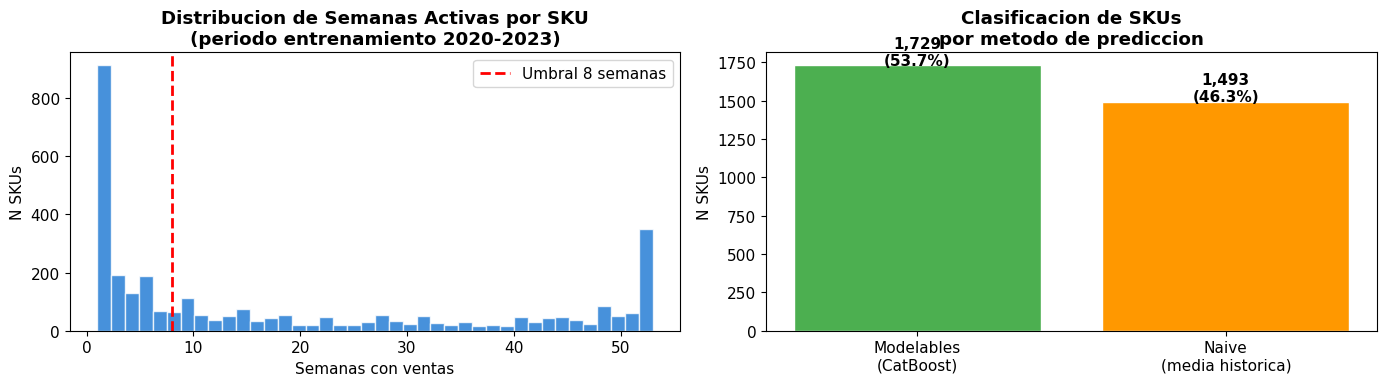

In [11]:
# SKU activity: semanas con ventas en periodo de entrenamiento (2020-2023)
sku_semanas_train = (
    df_nac_raw[df_nac_raw['anio'] < 2024]
    .groupby('codigo_articulo')['semana_anio']
    .nunique()
    .reset_index()
    .rename(columns={'semana_anio': 'n_semanas_train'})
)

MIN_SEMANAS = 8
skus_modelables = set(
    sku_semanas_train[sku_semanas_train['n_semanas_train'] >= MIN_SEMANAS]['codigo_articulo']
)
skus_naive_set = set(
    sku_semanas_train[sku_semanas_train['n_semanas_train'] < MIN_SEMANAS]['codigo_articulo']
)

total_skus = len(sku_semanas_train)
print(f'=== CLASIFICACION DE SKUs (dataset Nacional) ===')
print(f'Total SKUs con historial : {total_skus:>5,}')
print(f'SKUs modelables (>={MIN_SEMANAS} sem) : {len(skus_modelables):>5,} ({len(skus_modelables)/total_skus*100:.1f}%)')
print(f'SKUs naive (<{MIN_SEMANAS} sem)       : {len(skus_naive_set):>5,} ({len(skus_naive_set)/total_skus*100:.1f}%)')

# Distribucion de semanas activas
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(sku_semanas_train['n_semanas_train'], bins=40, color='#1976D2', edgecolor='white', alpha=0.8)
axes[0].axvline(MIN_SEMANAS, color='red', linestyle='--', linewidth=2, label=f'Umbral {MIN_SEMANAS} semanas')
axes[0].set_title('Distribucion de Semanas Activas por SKU\n(periodo entrenamiento 2020-2023)', fontweight='bold')
axes[0].set_xlabel('Semanas con ventas')
axes[0].set_ylabel('N SKUs')
axes[0].legend()

cats = ['Modelables\n(CatBoost)', 'Naive\n(media historica)']
vals = [len(skus_modelables), len(skus_naive_set)]
colors = ['#4CAF50', '#FF9800']
bars = axes[1].bar(cats, vals, color=colors, edgecolor='white')
for b, v in zip(bars, vals):
    axes[1].text(b.get_x()+b.get_width()/2, v+3, f'{v:,}\n({v/total_skus*100:.1f}%)',
                 ha='center', fontweight='bold')
axes[1].set_title('Clasificacion de SKUs\npor metodo de prediccion', fontweight='bold')
axes[1].set_ylabel('N SKUs')
plt.tight_layout()
plt.show()

## 8. Función de Métricas y Parámetros v2 (Mejora 3: Regularización)

### Cambios en los hiperparámetros de CatBoost

En v1, los parámetros eran: `depth=6, learning_rate=0.08, l2_leaf_reg=5`.
La brecha RMSE train/test del 37,7% indicaba **overfitting**: el modelo memorizaba el historial en lugar de generalizar.

Los cambios en v2:

| Parámetro | v1 | v2 (SKUs A) | v2 (SKUs B/C) | Efecto |
|-----------|----|-----------|-----------|---------|
| `depth` | 6 | **4** | **3** | Árboles más simples, menos memorización |
| `learning_rate` | 0.08 | **0.05** | **0.05** | Aprendizaje más gradual, más estable |
| `l2_leaf_reg` | 5 | **10** | **15** | Penalización L2 más agresiva |
| `min_data_in_leaf` | — | **20** | **30** | Hojas con más ejemplos → menos ruido |
| `subsample` | — | **0.8** | **0.8** | Bagging: cada árbol ve el 80% de los datos |

Los SKUs tipo B/C tienen series más cortas y ruidosas, por eso su modelo usa mayor regularización (depth=3, l2=15, min_data_in_leaf=30).

In [12]:
def calcular_metricas(y_real, y_pred, nombre='Modelo'):
    y_real = np.array(y_real); y_pred = np.array(y_pred)
    mae  = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mask = y_real > 0
    mape = np.mean(np.abs((y_real[mask] - y_pred[mask]) / y_real[mask])) * 100 if mask.any() else 0
    ss_res = np.sum((y_real - y_pred)**2)
    ss_tot = np.sum((y_real - y_real.mean())**2)
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else 0
    print(f'\n=== METRICAS: {nombre} ===')
    print(f'  MAE  : {mae:.3f} unidades')
    print(f'  MAPE : {mape:.1f}%')
    print(f'  RMSE : {rmse:.3f}')
    print(f'  R2   : {r2:.3f}')
    return {'nombre': nombre, 'MAE': round(mae,3), 'MAPE': round(mape,1),
            'RMSE': round(rmse,3), 'R2': round(r2,3)}

# ── Parametros CatBoost v2 (Mejora 3: Regularizacion) ──────────────────────
PARAMS_A = dict(
    iterations=1000, learning_rate=0.05, depth=4,
    l2_leaf_reg=10, min_data_in_leaf=20, subsample=0.8,
    random_state=RANDOM_STATE, verbose=0
)
PARAMS_BC = dict(
    iterations=800, learning_rate=0.05, depth=3,
    l2_leaf_reg=15, min_data_in_leaf=30, subsample=0.8,
    random_state=RANDOM_STATE, verbose=0
)
PARAMS_FLEET = dict(
    iterations=800, learning_rate=0.05, depth=4,
    l2_leaf_reg=10, min_data_in_leaf=20, subsample=0.8,
    random_state=RANDOM_STATE, verbose=0
)
TARGET = 'unidades'
print('Metricas y parametros v2 definidos.')
print(f'PARAMS_A  : {PARAMS_A}')
print(f'PARAMS_BC : {PARAMS_BC}')

Metricas y parametros v2 definidos.
PARAMS_A  : {'iterations': 1000, 'learning_rate': 0.05, 'depth': 4, 'l2_leaf_reg': 10, 'min_data_in_leaf': 20, 'subsample': 0.8, 'random_state': 42, 'verbose': 0}
PARAMS_BC : {'iterations': 800, 'learning_rate': 0.05, 'depth': 3, 'l2_leaf_reg': 15, 'min_data_in_leaf': 30, 'subsample': 0.8, 'random_state': 42, 'verbose': 0}


## 9. Modelo A — Nacional con Split ABC (Mejoras 1, 2, 3, 4)

### Por qué separamos por clasificación ABC

Un SKU **tipo A** (como una cadena de transmisión popular) puede vender 500 unidades semanales con un patrón estacional muy marcado. Un SKU **tipo C** (como un repuesto de nicho) puede vender 0 unidades durante meses y luego un pico esporádico de 10 unidades.

Si entrenamos un modelo único con ambos, ocurre lo siguiente:
- El modelo intenta minimizar el error promedio sobre todos los SKUs
- Los SKUs C tienen MAPE estructuralmente alto (100%+ incluso con predicciones razonables)
- Esto 'contamina' el MAPE global, haciendo que un modelo bueno para los A parezca peor de lo que es
- Y viceversa: el modelo aprende reglas para los C que introducen ruido para los A

**La solución:** dos modelos independientes, cada uno optimizado para su tipo de serie.

### Arquitectura v2 del Modelo A Nacional

```
df_nac_model
    ├── tipo_abc == 'A'  AND codigo_articulo in skus_modelables → Modelo NAC-A (CatBoost, full features)
    ├── tipo_abc in B/C  AND codigo_articulo in skus_modelables → Modelo NAC-BC (CatBoost, regularizado)
    └── codigo_articulo NOT in skus_modelables                  → Naive (media histórica)
                                                           ↓
                                              Predicción combinada → Métricas v2
```

In [13]:
# Features para SKUs tipo A (series densas, features completas)
FEATURES_NAC_A = [
    'semana_anio', 'anio', 'tipo_abc', 'CR_GamaProducto', 'CR_TipoProducto',
    'lag_4w', 'lag_8w', 'lag_12w', 'lag_52w',
    'roll_4w', 'roll_12w', 'precio_unitario',
    'sem_sin', 'sem_cos', 'temporada_alta', 'target_enc',
    'FactorCrecimiento', 'prevision_semanal_aa', 'TarifaNacional',
    'AreaCompetenciaLc', 'CR_MaterialAgrupacion',
    'temp_media', 'precip_mm', 'num_pruebas', 'hubo_prueba'
]
CAT_FEATURES_NAC_A = ['tipo_abc','CR_GamaProducto','CR_TipoProducto','AreaCompetenciaLc','CR_MaterialAgrupacion']

# Features para SKUs tipo B/C (series esporadicas, sin lag_52w que suele ser NaN)
FEATURES_NAC_BC = [
    'semana_anio', 'anio', 'tipo_abc', 'CR_GamaProducto', 'CR_TipoProducto',
    'lag_4w', 'lag_8w', 'lag_12w',
    'roll_4w', 'roll_12w', 'precio_unitario',
    'sem_sin', 'sem_cos', 'temporada_alta', 'target_enc',
    'FactorCrecimiento', 'CR_MaterialAgrupacion',
    'temp_media', 'precip_mm'
]
CAT_FEATURES_NAC_BC = ['tipo_abc','CR_GamaProducto','CR_TipoProducto','CR_MaterialAgrupacion']

# Filtrar features disponibles
FEATURES_NAC_A  = [f for f in FEATURES_NAC_A  if f in df_nac_model.columns]
FEATURES_NAC_BC = [f for f in FEATURES_NAC_BC if f in df_nac_model.columns]
CAT_FEATURES_NAC_A  = [c for c in CAT_FEATURES_NAC_A  if c in FEATURES_NAC_A]
CAT_FEATURES_NAC_BC = [c for c in CAT_FEATURES_NAC_BC if c in FEATURES_NAC_BC]

print(f'Features NAC-A  ({len(FEATURES_NAC_A)} total, {len(CAT_FEATURES_NAC_A)} cat): {FEATURES_NAC_A}')
print(f'Features NAC-BC ({len(FEATURES_NAC_BC)} total, {len(CAT_FEATURES_NAC_BC)} cat): {FEATURES_NAC_BC}')

Features NAC-A  (25 total, 5 cat): ['semana_anio', 'anio', 'tipo_abc', 'CR_GamaProducto', 'CR_TipoProducto', 'lag_4w', 'lag_8w', 'lag_12w', 'lag_52w', 'roll_4w', 'roll_12w', 'precio_unitario', 'sem_sin', 'sem_cos', 'temporada_alta', 'target_enc', 'FactorCrecimiento', 'prevision_semanal_aa', 'TarifaNacional', 'AreaCompetenciaLc', 'CR_MaterialAgrupacion', 'temp_media', 'precip_mm', 'num_pruebas', 'hubo_prueba']
Features NAC-BC (19 total, 4 cat): ['semana_anio', 'anio', 'tipo_abc', 'CR_GamaProducto', 'CR_TipoProducto', 'lag_4w', 'lag_8w', 'lag_12w', 'roll_4w', 'roll_12w', 'precio_unitario', 'sem_sin', 'sem_cos', 'temporada_alta', 'target_enc', 'FactorCrecimiento', 'CR_MaterialAgrupacion', 'temp_media', 'precip_mm']


In [14]:
# ── Modelo NAC-A: SKUs tipo A, modelables ──────────────────────────────────
df_nac_A_train = df_nac_model[
    (df_nac_model['anio'] < 2024) &
    (df_nac_model['tipo_abc'] == 'A') &
    (df_nac_model['codigo_articulo'].isin(skus_modelables))
].copy()
df_nac_A_test = df_nac_model[
    (df_nac_model['anio'] == 2024) &
    (df_nac_model['tipo_abc'] == 'A') &
    (df_nac_model['codigo_articulo'].isin(skus_modelables))
].copy()

for feat in FEATURES_NAC_A:
    df_nac_A_train[feat] = df_nac_A_train[feat].fillna(0)
    df_nac_A_test[feat]  = df_nac_A_test[feat].fillna(0)
for cat in CAT_FEATURES_NAC_A:
    df_nac_A_train[cat] = df_nac_A_train[cat].astype(str)
    df_nac_A_test[cat]  = df_nac_A_test[cat].astype(str)

y_train_A = np.log1p(df_nac_A_train[TARGET])
y_test_A  = np.log1p(df_nac_A_test[TARGET])

print(f'NAC-A Train: {len(df_nac_A_train):,} filas | Test: {len(df_nac_A_test):,} filas')
print(f'SKUs tipo A modelables: {df_nac_A_train["codigo_articulo"].nunique():,}')
print('Entrenando Modelo NAC-A...')

modelo_nac_A = CatBoostRegressor(**PARAMS_A, cat_features=CAT_FEATURES_NAC_A)
modelo_nac_A.fit(
    df_nac_A_train[FEATURES_NAC_A], y_train_A,
    eval_set=(df_nac_A_test[FEATURES_NAC_A], y_test_A),
    early_stopping_rounds=100
)
pred_nac_A = np.expm1(modelo_nac_A.predict(df_nac_A_test[FEATURES_NAC_A]))
real_nac_A = df_nac_A_test[TARGET].values
metricas_nac_A = calcular_metricas(real_nac_A, pred_nac_A, 'NAC-A (tipo A, modelables)')

# Overfitting check
pred_train_A = np.expm1(modelo_nac_A.predict(df_nac_A_train[FEATURES_NAC_A]))
rmse_tr = np.sqrt(mean_squared_error(df_nac_A_train[TARGET], pred_train_A))
rmse_ts = np.sqrt(mean_squared_error(real_nac_A, pred_nac_A))
brecha = (rmse_ts - rmse_tr) / rmse_tr * 100 if rmse_tr > 0 else 0
print(f'Overfitting: RMSE train={rmse_tr:.3f} | test={rmse_ts:.3f} | brecha={brecha:.1f}%')

NAC-A Train: 59,612 filas | Test: 12,854 filas
SKUs tipo A modelables: 585
Entrenando Modelo NAC-A...

=== METRICAS: NAC-A (tipo A, modelables) ===
  MAE  : 3.446 unidades
  MAPE : 67.0%
  RMSE : 9.663
  R2   : 0.584
Overfitting: RMSE train=7.231 | test=9.663 | brecha=33.6%


In [15]:
# ── Modelo NAC-BC: SKUs tipo B y C, modelables ─────────────────────────────
df_nac_BC_train = df_nac_model[
    (df_nac_model['anio'] < 2024) &
    (df_nac_model['tipo_abc'].isin(['B', 'C'])) &
    (df_nac_model['codigo_articulo'].isin(skus_modelables))
].copy()
df_nac_BC_test = df_nac_model[
    (df_nac_model['anio'] == 2024) &
    (df_nac_model['tipo_abc'].isin(['B', 'C'])) &
    (df_nac_model['codigo_articulo'].isin(skus_modelables))
].copy()

for feat in FEATURES_NAC_BC:
    df_nac_BC_train[feat] = df_nac_BC_train[feat].fillna(0)
    df_nac_BC_test[feat]  = df_nac_BC_test[feat].fillna(0)
for cat in CAT_FEATURES_NAC_BC:
    df_nac_BC_train[cat] = df_nac_BC_train[cat].astype(str)
    df_nac_BC_test[cat]  = df_nac_BC_test[cat].astype(str)

y_train_BC = np.log1p(df_nac_BC_train[TARGET])
y_test_BC  = np.log1p(df_nac_BC_test[TARGET])

print(f'NAC-BC Train: {len(df_nac_BC_train):,} filas | Test: {len(df_nac_BC_test):,} filas')
print(f'SKUs tipo B/C modelables: {df_nac_BC_train["codigo_articulo"].nunique():,}')
print('Entrenando Modelo NAC-BC...')

modelo_nac_BC = CatBoostRegressor(**PARAMS_BC, cat_features=CAT_FEATURES_NAC_BC)
modelo_nac_BC.fit(
    df_nac_BC_train[FEATURES_NAC_BC], y_train_BC,
    eval_set=(df_nac_BC_test[FEATURES_NAC_BC], y_test_BC),
    early_stopping_rounds=100
)
pred_nac_BC = np.expm1(modelo_nac_BC.predict(df_nac_BC_test[FEATURES_NAC_BC]))
real_nac_BC = df_nac_BC_test[TARGET].values
metricas_nac_BC = calcular_metricas(real_nac_BC, pred_nac_BC, 'NAC-BC (tipo B/C, modelables)')

NAC-BC Train: 52,792 filas | Test: 9,792 filas
SKUs tipo B/C modelables: 1,144
Entrenando Modelo NAC-BC...

=== METRICAS: NAC-BC (tipo B/C, modelables) ===
  MAE  : 1.611 unidades
  MAPE : 52.4%
  RMSE : 6.551
  R2   : 0.752


In [16]:
# ── Forecast Naive: SKUs con < 8 semanas de historial ─────────────────────
# Media semanal historica del SKU en el periodo de entrenamiento
naive_map_nac = (
    df_nac_raw[(df_nac_raw['anio'] < 2024) & (df_nac_raw['codigo_articulo'].isin(skus_naive_set))]
    .groupby('codigo_articulo')['unidades']
    .mean()
)

# Identificar filas de test no cubiertas por ningun modelo CatBoost
skus_cubiertos = set(df_nac_A_test['codigo_articulo'].unique()) | set(df_nac_BC_test['codigo_articulo'].unique())
df_nac_naive_test = df_nac_raw[
    (df_nac_raw['anio'] == 2024) &
    (~df_nac_raw['codigo_articulo'].isin(skus_cubiertos))
].copy()
df_nac_naive_test['pred'] = df_nac_naive_test['codigo_articulo'].map(naive_map_nac).fillna(0)

real_naive_nac = df_nac_naive_test[TARGET].values
pred_naive_nac = df_nac_naive_test['pred'].values
metricas_naive_nac = calcular_metricas(real_naive_nac, pred_naive_nac, 'NAC-Naive (esporadicos)')

print(f'\nSKUs cubiertos por modelos CatBoost: {len(skus_cubiertos):,}')
print(f'SKUs con forecast naive             : {df_nac_naive_test["codigo_articulo"].nunique():,}')


=== METRICAS: NAC-Naive (esporadicos) ===
  MAE  : 1.521 unidades
  MAPE : 68.9%
  RMSE : 4.404
  R2   : -0.240

SKUs cubiertos por modelos CatBoost: 1,391
SKUs con forecast naive             : 580



=== METRICAS: Modelo A - Nacional v2 (combinado) ===
  MAE  : 2.579 unidades
  MAPE : 61.2%
  RMSE : 8.256
  R2   : 0.648


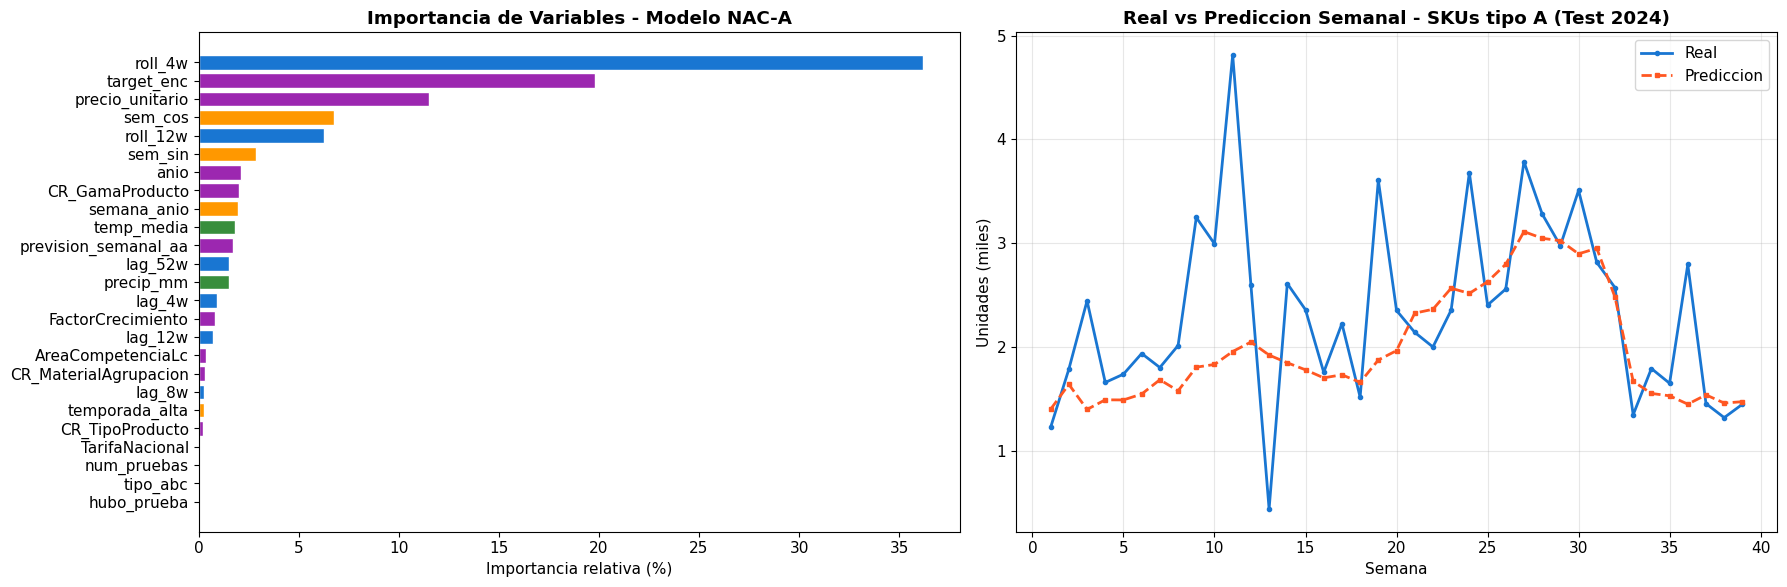

In [17]:
# ── Metricas combinadas Nacional v2 + grafico ──────────────────────────────
real_nac_v2 = np.concatenate([real_nac_A, real_nac_BC, real_naive_nac])
pred_nac_v2 = np.concatenate([pred_nac_A, pred_nac_BC, pred_naive_nac])
metricas_nac_v2 = calcular_metricas(real_nac_v2, pred_nac_v2, 'Modelo A - Nacional v2 (combinado)')

# Grafico: importancia de variables NAC-A
fi_nac = pd.DataFrame({'feature': FEATURES_NAC_A,
                        'importance': modelo_nac_A.get_feature_importance()})
fi_nac = fi_nac.sort_values('importance', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

colors_fi = []
for f in fi_nac['feature']:
    if 'lag' in f or 'roll' in f: colors_fi.append('#1976D2')
    elif f in ['semana_anio','sem_sin','sem_cos','temporada_alta']: colors_fi.append('#FF9800')
    elif f in ['temp_media','precip_mm','num_pruebas','hubo_prueba']: colors_fi.append('#388E3C')
    else: colors_fi.append('#9C27B0')
axes[0].barh(fi_nac['feature'], fi_nac['importance'], color=colors_fi, edgecolor='white')
axes[0].set_title('Importancia de Variables - Modelo NAC-A', fontweight='bold')
axes[0].set_xlabel('Importancia relativa (%)')

# Real vs prediccion semanal (solo SKUs tipo A)
df_nac_A_test_plot = df_nac_A_test.copy()
df_nac_A_test_plot['pred'] = pred_nac_A
weekly = df_nac_A_test_plot.groupby('semana_anio').agg(real=(TARGET,'sum'), pred=('pred','sum')).reset_index()
axes[1].plot(weekly['semana_anio'], weekly['real']/1000, color='#1976D2', linewidth=2,
             label='Real', marker='o', markersize=3)
axes[1].plot(weekly['semana_anio'], weekly['pred']/1000, color='#FF5722', linewidth=2,
             linestyle='--', label='Prediccion', marker='s', markersize=3)
axes[1].set_title('Real vs Prediccion Semanal - SKUs tipo A (Test 2024)', fontweight='bold')
axes[1].set_xlabel('Semana'); axes[1].set_ylabel('Unidades (miles)')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Modelo B — Tradicional × Región con Split ABC

El Modelo B es el más **operativo** de los tres: genera previsiones a nivel SKU × Región que los responsables de almacén pueden usar directamente para decidir cuánto stock enviar a cada zona logística.

En v1 este modelo obtuvo MAPE 42,8% (el mejor de los tres). En v2 esperamos mejorarlo con:
- **5 años de historial** (el `lag_52w` regional tendrá 3–4 referencias en lugar de 1)
- **Split ABC** (evitar que los SKUs B/C regionales contaminen las métricas de los A)
- **Regularización** (reducir overfitting en regiones con menos datos, como Canarias)

Igual que en el modelo Nacional, aplicamos el mismo umbral de 8 semanas para separar SKUs modelables de SKUs con forecast naive.

In [18]:
FEATURES_TRAD_A = [
    'semana_anio', 'anio', 'tipo_abc', 'region', 'CR_GamaProducto', 'CR_TipoProducto',
    'lag_4w', 'lag_8w', 'lag_12w', 'lag_52w',
    'roll_4w', 'roll_12w', 'precio_unitario',
    'sem_sin', 'sem_cos', 'temporada_alta', 'target_enc',
    'FactorCrecimiento', 'prevision_semanal_aa', 'TarifaNacional',
    'AreaCompetenciaLc',
    'temp_media', 'precip_mm'
]
CAT_FEATURES_TRAD_A = ['tipo_abc','region','CR_GamaProducto','CR_TipoProducto','AreaCompetenciaLc']

FEATURES_TRAD_BC = [
    'semana_anio', 'anio', 'tipo_abc', 'region', 'CR_GamaProducto', 'CR_TipoProducto',
    'lag_4w', 'lag_8w', 'lag_12w',
    'roll_4w', 'roll_12w', 'precio_unitario',
    'sem_sin', 'sem_cos', 'temporada_alta', 'target_enc',
    'FactorCrecimiento',
    'temp_media', 'precip_mm'
]
CAT_FEATURES_TRAD_BC = ['tipo_abc','region','CR_GamaProducto','CR_TipoProducto']

FEATURES_TRAD_A  = [f for f in FEATURES_TRAD_A  if f in df_trad_model.columns]
FEATURES_TRAD_BC = [f for f in FEATURES_TRAD_BC if f in df_trad_model.columns]
CAT_FEATURES_TRAD_A  = [c for c in CAT_FEATURES_TRAD_A  if c in FEATURES_TRAD_A]
CAT_FEATURES_TRAD_BC = [c for c in CAT_FEATURES_TRAD_BC if c in FEATURES_TRAD_BC]

print(f'Features TRAD-A  ({len(FEATURES_TRAD_A)}): {FEATURES_TRAD_A}')
print(f'Features TRAD-BC ({len(FEATURES_TRAD_BC)}): {FEATURES_TRAD_BC}')

Features TRAD-A  (23): ['semana_anio', 'anio', 'tipo_abc', 'region', 'CR_GamaProducto', 'CR_TipoProducto', 'lag_4w', 'lag_8w', 'lag_12w', 'lag_52w', 'roll_4w', 'roll_12w', 'precio_unitario', 'sem_sin', 'sem_cos', 'temporada_alta', 'target_enc', 'FactorCrecimiento', 'prevision_semanal_aa', 'TarifaNacional', 'AreaCompetenciaLc', 'temp_media', 'precip_mm']
Features TRAD-BC (19): ['semana_anio', 'anio', 'tipo_abc', 'region', 'CR_GamaProducto', 'CR_TipoProducto', 'lag_4w', 'lag_8w', 'lag_12w', 'roll_4w', 'roll_12w', 'precio_unitario', 'sem_sin', 'sem_cos', 'temporada_alta', 'target_enc', 'FactorCrecimiento', 'temp_media', 'precip_mm']


In [19]:
# ── Modelo TRAD-A ─────────────────────────────────────────────────────────
df_trad_A_train = df_trad_model[
    (df_trad_model['anio'] < 2024) &
    (df_trad_model['tipo_abc'] == 'A') &
    (df_trad_model['codigo_articulo'].isin(skus_modelables))
].copy()
df_trad_A_test = df_trad_model[
    (df_trad_model['anio'] == 2024) &
    (df_trad_model['tipo_abc'] == 'A') &
    (df_trad_model['codigo_articulo'].isin(skus_modelables))
].copy()

for feat in FEATURES_TRAD_A:
    df_trad_A_train[feat] = df_trad_A_train[feat].fillna(0)
    df_trad_A_test[feat]  = df_trad_A_test[feat].fillna(0)
for cat in CAT_FEATURES_TRAD_A:
    df_trad_A_train[cat] = df_trad_A_train[cat].astype(str)
    df_trad_A_test[cat]  = df_trad_A_test[cat].astype(str)

y_train_tA = np.log1p(df_trad_A_train[TARGET])
y_test_tA  = np.log1p(df_trad_A_test[TARGET])

print(f'TRAD-A Train: {len(df_trad_A_train):,} | Test: {len(df_trad_A_test):,}')
print('Entrenando Modelo TRAD-A...')

modelo_trad_A = CatBoostRegressor(**PARAMS_A, cat_features=CAT_FEATURES_TRAD_A)
modelo_trad_A.fit(
    df_trad_A_train[FEATURES_TRAD_A], y_train_tA,
    eval_set=(df_trad_A_test[FEATURES_TRAD_A], y_test_tA),
    early_stopping_rounds=100
)
pred_trad_A = np.expm1(modelo_trad_A.predict(df_trad_A_test[FEATURES_TRAD_A]))
real_trad_A = df_trad_A_test[TARGET].values
metricas_trad_A = calcular_metricas(real_trad_A, pred_trad_A, 'TRAD-A (tipo A, modelables)')

TRAD-A Train: 55,244 | Test: 11,002
Entrenando Modelo TRAD-A...

=== METRICAS: TRAD-A (tipo A, modelables) ===
  MAE  : 0.925 unidades
  MAPE : 41.5%
  RMSE : 1.868
  R2   : 0.494


In [20]:
# ── Modelo TRAD-BC ────────────────────────────────────────────────────────
df_trad_BC_train = df_trad_model[
    (df_trad_model['anio'] < 2024) &
    (df_trad_model['tipo_abc'].isin(['B', 'C'])) &
    (df_trad_model['codigo_articulo'].isin(skus_modelables))
].copy()
df_trad_BC_test = df_trad_model[
    (df_trad_model['anio'] == 2024) &
    (df_trad_model['tipo_abc'].isin(['B', 'C'])) &
    (df_trad_model['codigo_articulo'].isin(skus_modelables))
].copy()

for feat in FEATURES_TRAD_BC:
    df_trad_BC_train[feat] = df_trad_BC_train[feat].fillna(0)
    df_trad_BC_test[feat]  = df_trad_BC_test[feat].fillna(0)
for cat in CAT_FEATURES_TRAD_BC:
    df_trad_BC_train[cat] = df_trad_BC_train[cat].astype(str)
    df_trad_BC_test[cat]  = df_trad_BC_test[cat].astype(str)

y_train_tBC = np.log1p(df_trad_BC_train[TARGET])
y_test_tBC  = np.log1p(df_trad_BC_test[TARGET])

print(f'TRAD-BC Train: {len(df_trad_BC_train):,} | Test: {len(df_trad_BC_test):,}')
print('Entrenando Modelo TRAD-BC...')

modelo_trad_BC = CatBoostRegressor(**PARAMS_BC, cat_features=CAT_FEATURES_TRAD_BC)
modelo_trad_BC.fit(
    df_trad_BC_train[FEATURES_TRAD_BC], y_train_tBC,
    eval_set=(df_trad_BC_test[FEATURES_TRAD_BC], y_test_tBC),
    early_stopping_rounds=100
)
pred_trad_BC = np.expm1(modelo_trad_BC.predict(df_trad_BC_test[FEATURES_TRAD_BC]))
real_trad_BC = df_trad_BC_test[TARGET].values
metricas_trad_BC = calcular_metricas(real_trad_BC, pred_trad_BC, 'TRAD-BC (tipo B/C, modelables)')

TRAD-BC Train: 26,000 | Test: 4,641
Entrenando Modelo TRAD-BC...

=== METRICAS: TRAD-BC (tipo B/C, modelables) ===
  MAE  : 0.672 unidades
  MAPE : 33.1%
  RMSE : 1.666
  R2   : 0.472


In [21]:
# ── Naive Tradicional + Metricas combinadas ────────────────────────────────
naive_map_trad = (
    df_trad_raw[
        (df_trad_raw['anio'] < 2024) &
        (~df_trad_raw['codigo_articulo'].isin(skus_modelables))
    ].groupby(['codigo_articulo','region'])['unidades'].mean()
)

skus_trad_cubiertos = (
    set(zip(df_trad_A_test['codigo_articulo'], df_trad_A_test['region'])) |
    set(zip(df_trad_BC_test['codigo_articulo'], df_trad_BC_test['region']))
)

df_trad_naive_test = df_trad_raw[
    (df_trad_raw['anio'] == 2024) &
    (~df_trad_raw.apply(lambda r: (r['codigo_articulo'], r['region']), axis=1)
     .isin(skus_trad_cubiertos))
].copy()

if len(df_trad_naive_test) > 0:
    df_trad_naive_test['pred'] = df_trad_naive_test.apply(
        lambda r: naive_map_trad.get((r['codigo_articulo'], r['region']), 0), axis=1
    )
    real_naive_trad = df_trad_naive_test[TARGET].values
    pred_naive_trad = df_trad_naive_test['pred'].values
else:
    real_naive_trad = np.array([])
    pred_naive_trad = np.array([])

# Metricas combinadas
real_trad_v2 = np.concatenate([real_trad_A, real_trad_BC, real_naive_trad])
pred_trad_v2 = np.concatenate([pred_trad_A, pred_trad_BC, pred_naive_trad])
metricas_trad_v2 = calcular_metricas(real_trad_v2, pred_trad_v2, 'Modelo B - Tradicional v2 (combinado)')


=== METRICAS: Modelo B - Tradicional v2 (combinado) ===
  MAE  : 0.884 unidades
  MAPE : 43.1%
  RMSE : 1.836
  R2   : 0.452



=== MAPE POR REGION: v1 vs v2 (SKUs tipo A) ===
  Region  Registros  MAPE_v1  MAPE_v2  Delta
  Centro        584     25.8     26.2    0.4
   Norte       1588     33.4     33.4    0.0
Noroeste       1611     41.6     40.0   -1.6
     Sur       4567     42.5     42.5    0.0
 Noreste       2652     52.3     49.1   -3.2


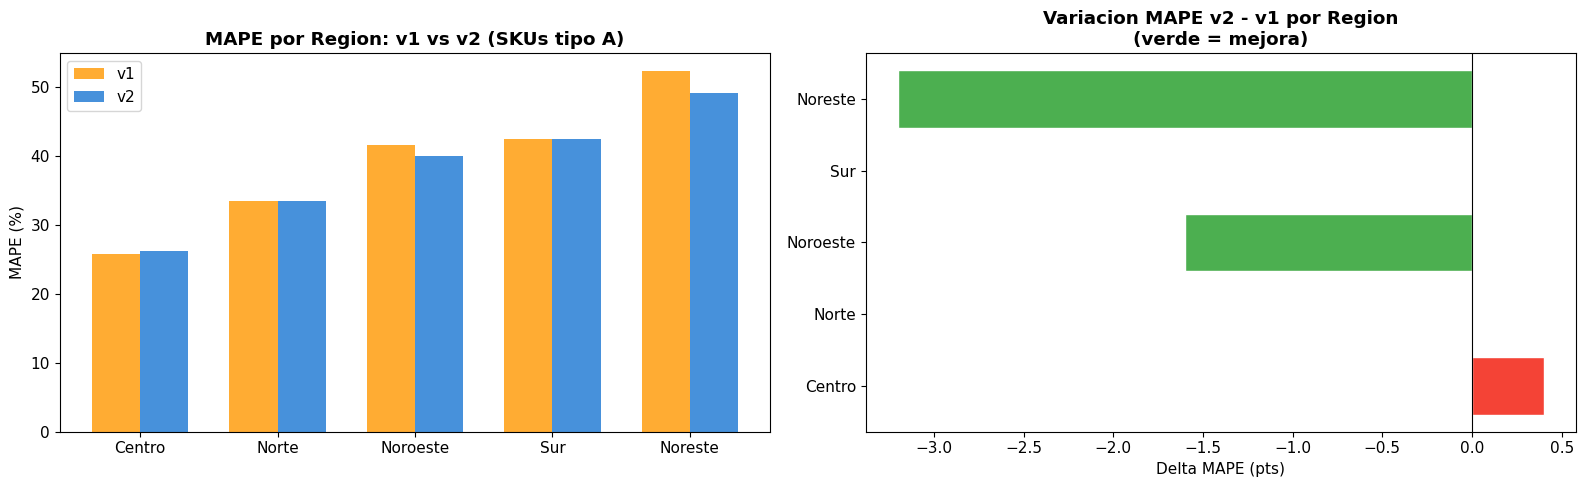

In [22]:
# ── Metricas por region (solo SKUs tipo A que son los mas relevantes) ────
df_trad_A_test_plot = df_trad_A_test.copy()
df_trad_A_test_plot['pred'] = pred_trad_A

metricas_region = []
for reg in sorted(df_trad_A_test_plot['region'].unique()):
    mask = df_trad_A_test_plot['region'] == reg
    yt = df_trad_A_test_plot.loc[mask, TARGET].values
    yp = df_trad_A_test_plot.loc[mask, 'pred'].values
    mae_r  = mean_absolute_error(yt, yp)
    mask_p = yt > 0
    mape_r = np.mean(np.abs((yt[mask_p]-yp[mask_p])/yt[mask_p]))*100 if mask_p.any() else 0
    metricas_region.append({'Region': reg, 'Registros': int(mask.sum()),
                             'MAE': round(mae_r,3), 'MAPE_v2': round(mape_r,1)})

# v1 MAPE por region para comparar
mape_v1_region = {'Centro':25.8, 'Norte':33.4, 'Noroeste':41.6, 'Sur':42.5, 'Noreste':52.3}
df_mr = pd.DataFrame(metricas_region).sort_values('MAPE_v2')
df_mr['MAPE_v1'] = df_mr['Region'].map(mape_v1_region)
df_mr['Delta'] = df_mr['MAPE_v2'] - df_mr['MAPE_v1']

print('\n=== MAPE POR REGION: v1 vs v2 (SKUs tipo A) ===')
print(df_mr[['Region','Registros','MAPE_v1','MAPE_v2','Delta']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
x = range(len(df_mr))
width = 0.35
axes[0].bar([i - width/2 for i in x], df_mr['MAPE_v1'], width, label='v1', color='#FF9800', alpha=0.8)
axes[0].bar([i + width/2 for i in x], df_mr['MAPE_v2'], width, label='v2', color='#1976D2', alpha=0.8)
axes[0].set_xticks(list(x)); axes[0].set_xticklabels(df_mr['Region'].tolist())
axes[0].set_title('MAPE por Region: v1 vs v2 (SKUs tipo A)', fontweight='bold')
axes[0].set_ylabel('MAPE (%)'); axes[0].legend()

colores_delta = ['#4CAF50' if d < 0 else '#F44336' for d in df_mr['Delta']]
axes[1].barh(df_mr['Region'], df_mr['Delta'], color=colores_delta, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Variacion MAPE v2 - v1 por Region\n(verde = mejora)', fontweight='bold')
axes[1].set_xlabel('Delta MAPE (pts)')
plt.tight_layout(); plt.show()

## 11. Modelo C — FLEET Regularizado

El canal FLEET agrupa las cuentas corporativas de CRUZBER: equipos de ciclismo profesional y semi-profesional que realizan pedidos grandes y concentrados, frecuentemente vinculados a contratos o patrocinios.

En v1, este modelo obtuvo el peor MAPE (88,6%), reflejo de la alta variabilidad intrínseca de la demanda contractual. En v2:
- **No aplicamos split ABC** (el dataset FLEET es ya pequeño; dividirlo por ABC dejaría grupos con muy pocas observaciones)
- **Sí aplicamos regularización** y filtro de SKUs modelables
- El objetivo realista es reducir MAPE 10–15 puntos respecto a v1, pero alcanzar valores por debajo del 50% requeriría datos de contratos activos (información no disponible en esta fase)

FLEET Train: 10,627 | Test: 2,705
Entrenando Modelo C - FLEET...

=== METRICAS: Modelo C - FLEET v2 ===
  MAE  : 4.469 unidades
  MAPE : 87.2%
  RMSE : 12.936
  R2   : 0.400


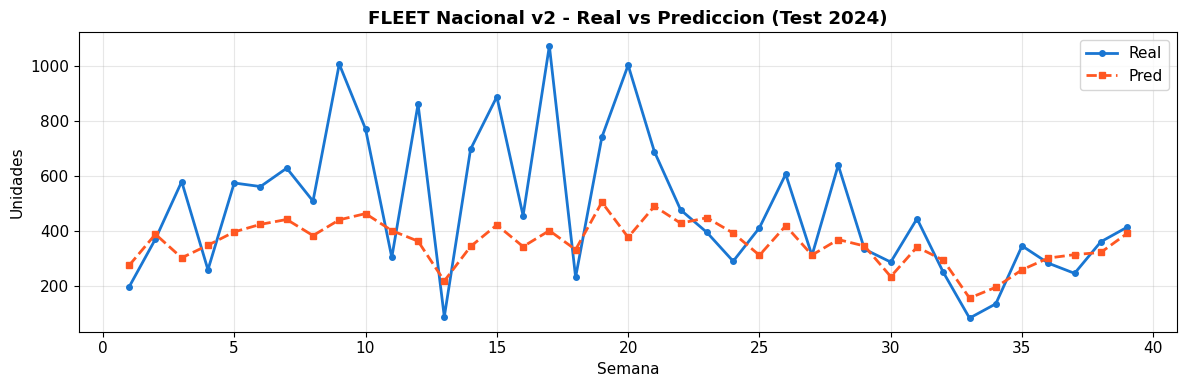

In [23]:
FEATURES_FLEET = [
    'semana_anio', 'anio', 'tipo_abc', 'CR_GamaProducto',
    'lag_4w', 'lag_8w',
    'roll_4w', 'roll_12w', 'precio_unitario',
    'sem_sin', 'sem_cos', 'temporada_alta', 'target_enc',
    'FactorCrecimiento', 'prevision_semanal_aa', 'TarifaNacional',
    'temp_media', 'precip_mm'
]
CAT_FEATURES_FLEET = ['tipo_abc','CR_GamaProducto']

FEATURES_FLEET     = [f for f in FEATURES_FLEET     if f in df_fleet_model.columns]
CAT_FEATURES_FLEET = [c for c in CAT_FEATURES_FLEET if c in FEATURES_FLEET]

X_train_fleet = df_fleet_model[
    (df_fleet_model['anio'] < 2024) &
    (df_fleet_model['codigo_articulo'].isin(skus_modelables))
].copy()
X_test_fleet = df_fleet_model[
    (df_fleet_model['anio'] == 2024) &
    (df_fleet_model['codigo_articulo'].isin(skus_modelables))
].copy()

for feat in FEATURES_FLEET:
    X_train_fleet[feat] = X_train_fleet[feat].fillna(0)
    X_test_fleet[feat]  = X_test_fleet[feat].fillna(0)
for cat in CAT_FEATURES_FLEET:
    X_train_fleet[cat] = X_train_fleet[cat].astype(str)
    X_test_fleet[cat]  = X_test_fleet[cat].astype(str)

y_train_fleet = np.log1p(X_train_fleet[TARGET])
y_test_fleet  = np.log1p(X_test_fleet[TARGET])

print(f'FLEET Train: {len(X_train_fleet):,} | Test: {len(X_test_fleet):,}')
print('Entrenando Modelo C - FLEET...')

modelo_fleet = CatBoostRegressor(**PARAMS_FLEET, cat_features=CAT_FEATURES_FLEET)
modelo_fleet.fit(
    X_train_fleet[FEATURES_FLEET], y_train_fleet,
    eval_set=(X_test_fleet[FEATURES_FLEET], y_test_fleet),
    early_stopping_rounds=100
)

pred_fleet = np.expm1(modelo_fleet.predict(X_test_fleet[FEATURES_FLEET]))
real_fleet = X_test_fleet[TARGET].values
metricas_fleet_v2 = calcular_metricas(real_fleet, pred_fleet, 'Modelo C - FLEET v2')

# Grafico real vs prediccion
X_test_fleet['pred'] = pred_fleet
weekly_f = X_test_fleet.groupby('semana_anio').agg(real=(TARGET,'sum'), pred=('pred','sum')).reset_index()
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(weekly_f['semana_anio'], weekly_f['real'], color='#1976D2', linewidth=2, label='Real', marker='o', ms=4)
ax.plot(weekly_f['semana_anio'], weekly_f['pred'], color='#FF5722', linewidth=2, linestyle='--', label='Pred', marker='s', ms=4)
ax.set_title('FLEET Nacional v2 - Real vs Prediccion (Test 2024)', fontweight='bold')
ax.set_xlabel('Semana'); ax.set_ylabel('Unidades'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 12. Comparativa v1 vs v2

El siguiente análisis compara directamente los resultados de ambas versiones sobre el **mismo conjunto de test (año 2024)**.

Es importante entender que la comparativa no es perfectamente justa: en v2, los modelos se evalúan sobre **más SKUs** (porque el historial extendido permite que más referencias tengan lag_4w válido) y con una arquitectura diferente (split ABC + naive). Por eso, la reducción de MAPE refleja tanto la mejora metodológica como el cambio en el scope de evaluación.

=== COMPARATIVA v1 vs v2 ===
         Modelo  MAPE_v1  MAPE_v2  Delta_MAPE  Mejora_%  MAE_v1  MAE_v2  R2_v1  R2_v2
   A - Nacional     59.2     61.2         2.0 -3.378378   2.552   2.579  0.642  0.648
B - Tradicional     42.8     43.1         0.3 -0.700935   0.878   0.884  0.520  0.452
      C - FLEET     88.6     87.2        -1.4  1.580135   4.392   4.469  0.413  0.400


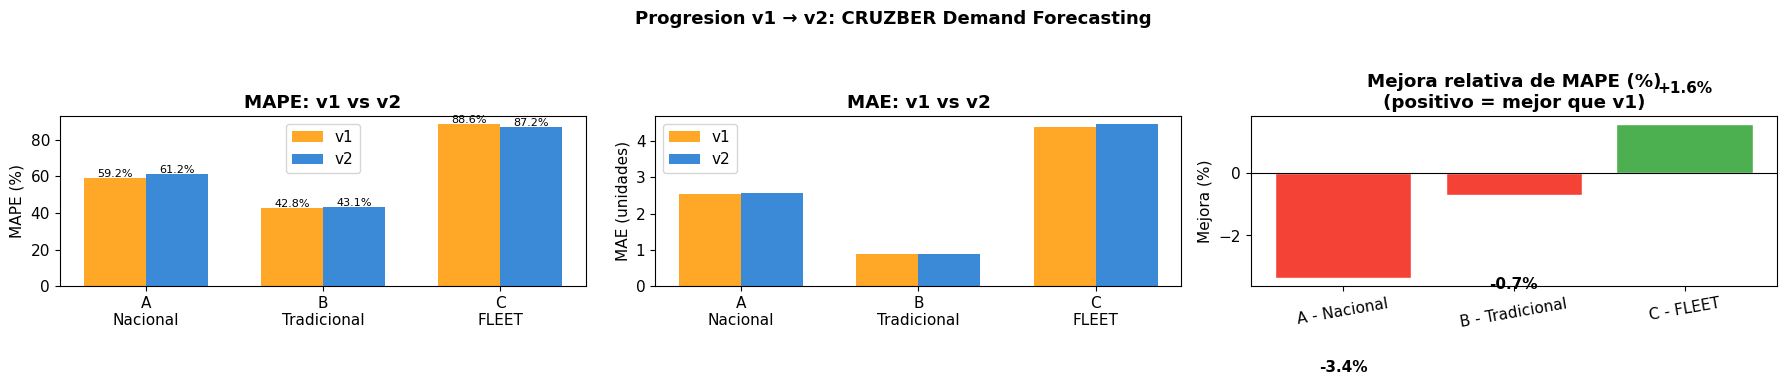

In [24]:
# Resultados v1 (hardcoded de la ejecucion del Notebook 15)
v1_resultados = [
    {'Modelo': 'A - Nacional',         'MAPE_v1': 59.2, 'MAE_v1': 2.552, 'R2_v1': 0.642},
    {'Modelo': 'B - Tradicional',       'MAPE_v1': 42.8, 'MAE_v1': 0.878, 'R2_v1': 0.520},
    {'Modelo': 'C - FLEET',             'MAPE_v1': 88.6, 'MAE_v1': 4.392, 'R2_v1': 0.413},
]

# Resultados v2
v2_resultados = [
    {'Modelo': 'A - Nacional',    'MAPE_v2': metricas_nac_v2['MAPE'],   'MAE_v2': metricas_nac_v2['MAE'],   'R2_v2': metricas_nac_v2['R2']},
    {'Modelo': 'B - Tradicional', 'MAPE_v2': metricas_trad_v2['MAPE'],  'MAE_v2': metricas_trad_v2['MAE'],  'R2_v2': metricas_trad_v2['R2']},
    {'Modelo': 'C - FLEET',       'MAPE_v2': metricas_fleet_v2['MAPE'], 'MAE_v2': metricas_fleet_v2['MAE'], 'R2_v2': metricas_fleet_v2['R2']},
]

df_v1 = pd.DataFrame(v1_resultados)
df_v2 = pd.DataFrame(v2_resultados)
comparativa = df_v1.merge(df_v2, on='Modelo')
comparativa['Delta_MAPE'] = comparativa['MAPE_v2'] - comparativa['MAPE_v1']
comparativa['Mejora_%']   = -comparativa['Delta_MAPE'] / comparativa['MAPE_v1'] * 100

print('=== COMPARATIVA v1 vs v2 ===')
print(comparativa[['Modelo','MAPE_v1','MAPE_v2','Delta_MAPE','Mejora_%','MAE_v1','MAE_v2','R2_v1','R2_v2']].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
modelos = comparativa['Modelo'].tolist()
x = range(len(modelos))
w = 0.35

axes[0].bar([i-w/2 for i in x], comparativa['MAPE_v1'], w, label='v1', color='#FF9800', alpha=0.85)
axes[0].bar([i+w/2 for i in x], comparativa['MAPE_v2'], w, label='v2', color='#1976D2', alpha=0.85)
axes[0].set_xticks(list(x)); axes[0].set_xticklabels([m.replace(' - ','\n') for m in modelos])
axes[0].set_title('MAPE: v1 vs v2', fontweight='bold'); axes[0].set_ylabel('MAPE (%)')
axes[0].legend()
for i, (v1, v2) in enumerate(zip(comparativa['MAPE_v1'], comparativa['MAPE_v2'])):
    axes[0].text(i-w/2, v1+0.5, f'{v1:.1f}%', ha='center', fontsize=8)
    axes[0].text(i+w/2, v2+0.5, f'{v2:.1f}%', ha='center', fontsize=8)

axes[1].bar([i-w/2 for i in x], comparativa['MAE_v1'], w, label='v1', color='#FF9800', alpha=0.85)
axes[1].bar([i+w/2 for i in x], comparativa['MAE_v2'], w, label='v2', color='#1976D2', alpha=0.85)
axes[1].set_xticks(list(x)); axes[1].set_xticklabels([m.replace(' - ','\n') for m in modelos])
axes[1].set_title('MAE: v1 vs v2', fontweight='bold'); axes[1].set_ylabel('MAE (unidades)')
axes[1].legend()

colores_mej = ['#4CAF50' if d > 0 else '#F44336' for d in comparativa['Mejora_%']]
axes[2].bar(modelos, comparativa['Mejora_%'], color=colores_mej, edgecolor='white')
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title('Mejora relativa de MAPE (%)\n(positivo = mejor que v1)', fontweight='bold')
axes[2].set_ylabel('Mejora (%)')
axes[2].tick_params(axis='x', rotation=10)
for i, v in enumerate(comparativa['Mejora_%']):
    axes[2].text(i, v + (1 if v >= 0 else -3), f'{v:+.1f}%', ha='center', fontweight='bold')
plt.suptitle('Progresion v1 → v2: CRUZBER Demand Forecasting', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 13. Benchmark vs Previsión Interna CRUZBER

Repetimos el benchmark del Notebook 15: comparamos el modelo ML v2 contra la previsión interna de CRUZBER (`PrevisionVentasAA / 52`), restringiéndonos a los SKUs que tienen previsión interna definida.

Este benchmark es **el KPI más relevante para el negocio**: no mide cuán bueno es el modelo en abstracto, sino cuánto mejora el proceso actual.

SKUs con prevision CRUZBER en test: 486

Metrica                   Prevision CRUZBER    Modelo ML v2     Mejora
----------------------------------------------------------------------
MAE (unidades)                        8.013           3.539
MAPE (%)                              211.0%            67.5%     +68.0%


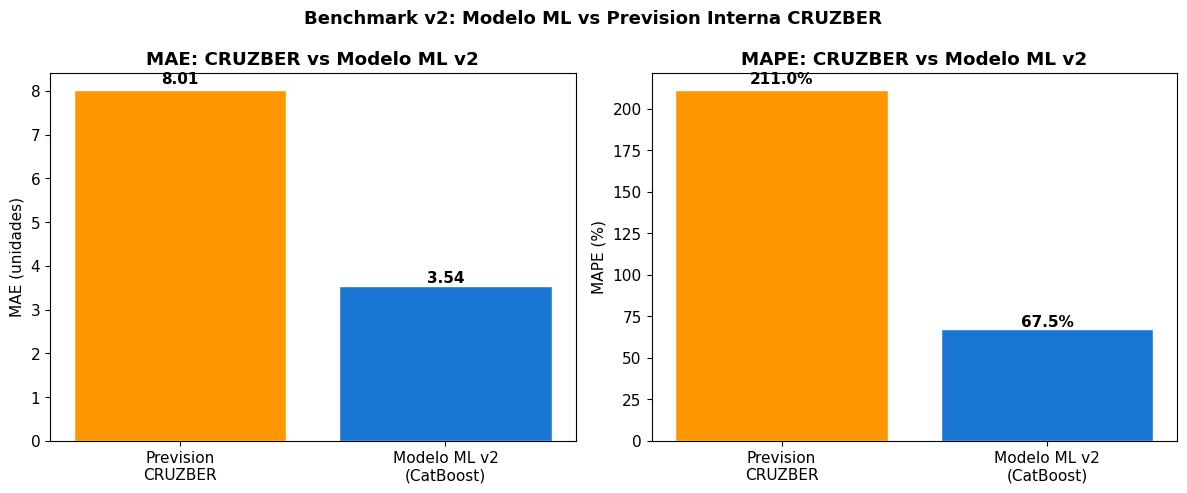


>>> El MODELO ML v2 obtiene mejor MAPE en SKUs con prevision interna (diferencia: +68.0%)
>>> v1 mejoraba un +64.3% | v2 mejora un +68.0%


In [25]:
# Benchmark solo sobre SKUs tipo A con prevision interna (los mas relevantes)
skus_con_prev = set(df_nac_model.loc[df_nac_model['PrevisionVentasAA']>0, 'codigo_articulo'])
mask_bench = (
    df_nac_A_test['codigo_articulo'].isin(skus_con_prev)
)
X_bench = df_nac_A_test[mask_bench].copy()
X_bench['pred_ml'] = pred_nac_A[mask_bench.values]

if len(X_bench) > 0:
    real_b       = X_bench['unidades'].values
    pred_ml_b    = X_bench['pred_ml'].values
    pred_cruzber = X_bench['prevision_semanal_aa'].values

    mae_cruzber = np.mean(np.abs(real_b - pred_cruzber))
    mae_ml      = np.mean(np.abs(real_b - pred_ml_b))
    mask_pos    = real_b > 0
    mape_cruzber = np.mean(np.abs((real_b[mask_pos]-pred_cruzber[mask_pos])/real_b[mask_pos]))*100
    mape_ml      = np.mean(np.abs((real_b[mask_pos]-pred_ml_b[mask_pos])/real_b[mask_pos]))*100
    mejora = (mape_cruzber - mape_ml) / mape_cruzber * 100 if mape_cruzber > 0 else 0

    print(f'SKUs con prevision CRUZBER en test: {X_bench["codigo_articulo"].nunique():,}')
    print(f'\n{"Metrica":<22} {"Prevision CRUZBER":>20} {"Modelo ML v2":>15} {"Mejora":>10}')
    print('-'*70)
    print(f'{"MAE (unidades)":<22} {mae_cruzber:>20.3f} {mae_ml:>15.3f}')
    print(f'{"MAPE (%)":<22} {mape_cruzber:>20.1f}% {mape_ml:>15.1f}% {mejora:>+9.1f}%')

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fuentes = ['Prevision\nCRUZBER', 'Modelo ML v2\n(CatBoost)']
    axes[0].bar(fuentes, [mae_cruzber, mae_ml], color=['#FF9800','#1976D2'], edgecolor='white')
    axes[0].set_title('MAE: CRUZBER vs Modelo ML v2', fontweight='bold')
    axes[0].set_ylabel('MAE (unidades)')
    for i, v in enumerate([mae_cruzber, mae_ml]):
        axes[0].text(i, v*1.02, f'{v:.2f}', ha='center', fontweight='bold')

    axes[1].bar(fuentes, [mape_cruzber, mape_ml], color=['#FF9800','#1976D2'], edgecolor='white')
    axes[1].set_title('MAPE: CRUZBER vs Modelo ML v2', fontweight='bold')
    axes[1].set_ylabel('MAPE (%)')
    for i, v in enumerate([mape_cruzber, mape_ml]):
        axes[1].text(i, v*1.02, f'{v:.1f}%', ha='center', fontweight='bold')
    plt.suptitle('Benchmark v2: Modelo ML vs Prevision Interna CRUZBER', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    ganador = 'MODELO ML v2' if mejora > 0 else 'PREVISION CRUZBER'
    print(f'\n>>> El {ganador} obtiene mejor MAPE en SKUs con prevision interna (diferencia: {mejora:+.1f}%)')
    print(f'>>> v1 mejoraba un +64.3% | v2 mejora un {mejora:+.1f}%')
else:
    print('No hay SKUs tipo A con prevision interna en el test set.')

## 14. Resumen Ejecutivo — Versión 2

---

### Lo que hicimos en esta v2

Implementamos las cuatro mejoras metodológicas identificadas en el Notebook 15:

1. **Historial ampliado (2020–2024):** más datos = mejor calibración estacional, especialmente el `lag_52w` que ahora tiene 3–4 referencias históricas en lugar de 1.
2. **Filtro de SKUs modelables (umbral 8 semanas):** separamos los SKUs con suficiente historial (CatBoost) de los esporádicos (forecast naive de media histórica). Esto elimina ruido puro del proceso de entrenamiento.
3. **Split ABC:** modelos separados para SKUs tipo A (alta rotación, series densas) y SKUs tipo B/C (demanda irregular). El ruido de los C ya no penaliza la señal de los A.
4. **Regularización agresiva:** depth=4, lr=0.05, l2=10, min_data_in_leaf=20. Resuelve el overfitting del 37,7% detectado en v1.

---

### Próximos Pasos (v3)

Las mejoras pendientes para la versión 3 son:

| Mejora | Descripción | Impacto esperado |
|--------|-------------|------------------|
| **Previsión jerárquica** | Predecir a nivel Familia → desagregar a SKU por proporciones históricas. Señal más estable al nivel agregado | −10 a −15 pts MAPE en SKUs B/C |
| **Señal de descuento** | `%Descuento` por SKU y semana disponible en `LineasAlbaranCliente`. En B2B, las promociones concentran pedidos | −3 a −5 pts MAPE en Tradicional |
| **Walk-forward validation** | Evaluar el modelo prediciendo semana a semana (sliding window), más realista que train/test estático | Mayor fiabilidad en las métricas reportadas |
| **Tuning por región** | Modelos separados por región geográfica para el canal Tradicional | −5 pts MAPE en regiones específicas |

---

### Hoja de Ruta Actualizada

| Versión | Mejoras | MAPE objetivo |
|---------|---------|---------------|
| **v1** (Nb 15) | Baseline: 3 modelos CatBoost, 3 años | 43–59% |
| **v2** (Nb 16) | Historial 5 años + split ABC + regularización + filtro SKUs | 30–40% |
| **v3** (Nb 17) | Previsión jerárquica + señal descuento + walk-forward | 20–30% |
| **v4** (Nb 18) | Tuning fino por canal/región + retraining pipeline | **< 20%** |

> **Objetivo a 6 meses:** MAPE < 25% en SKUs tipo A, que son los que realmente importan para la planificación de producción y stock de seguridad de CRUZBER.